In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

df = pd.read_csv("Stock Prices Data Set.csv")
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  str    
 1   date    497472 non-null  str    
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 26.6 MB


In [5]:
print(df.columns.tolist())

['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']


In [6]:
df['symbol'].unique()

<StringArray>
[ 'AAL', 'AAPL',  'AAP', 'ABBV',  'ABC',  'ABT',  'ACN', 'ADBE',  'ADI',
  'ADM',
 ...
 'WLTW',   'UA',  'FTV', 'EVHC',  'HLT',  'DXC', 'BHGE',  'BHF', 'DWDP',
 'APTV']
Length: 505, dtype: str

In [7]:
df_single = df[df['symbol'] == 'AAPL'].copy()

In [9]:
df_single['date'] = pd.to_datetime(df_single['date'], format='%d-%m-%Y')
df_single = df_single.sort_values('date')
df_single.set_index('date', inplace=True)

In [10]:
df_single.head()
df_single.shape

(1007, 6)

In [11]:
df_single.head()
df_single.shape

(1007, 6)

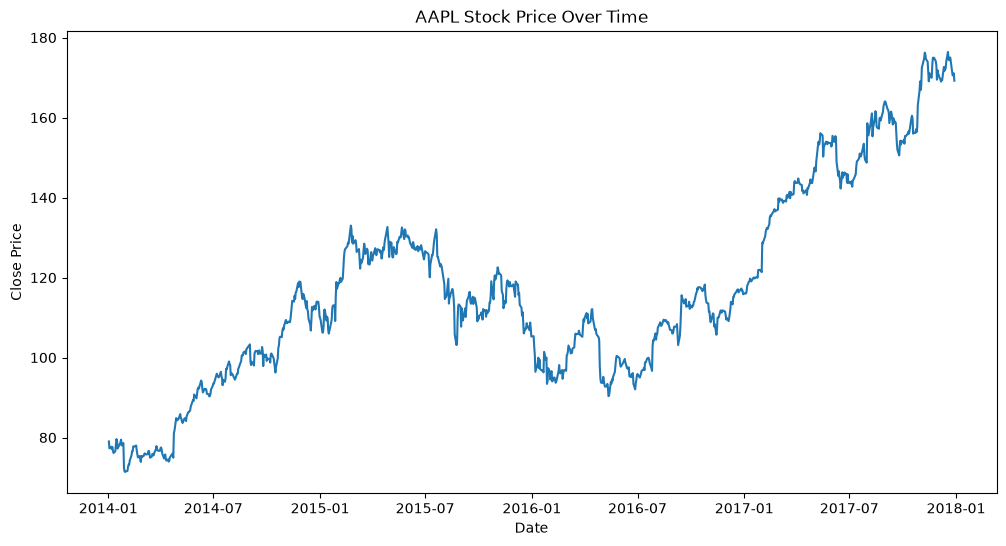

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(df_single['close'])
plt.title('AAPL Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

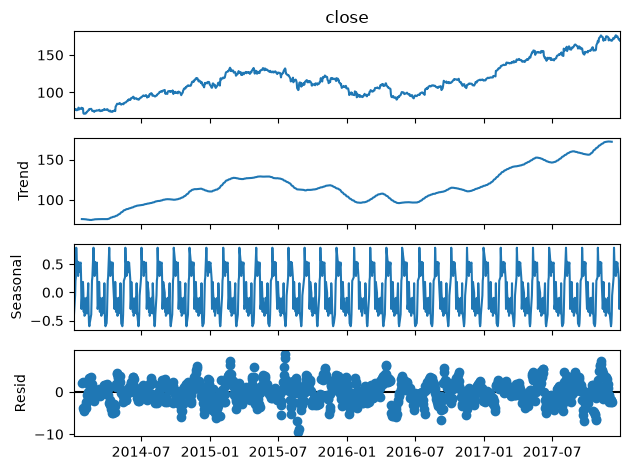

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
result = seasonal_decompose(df_single['close'], model='additive', period=30)

result.plot()
plt.show()

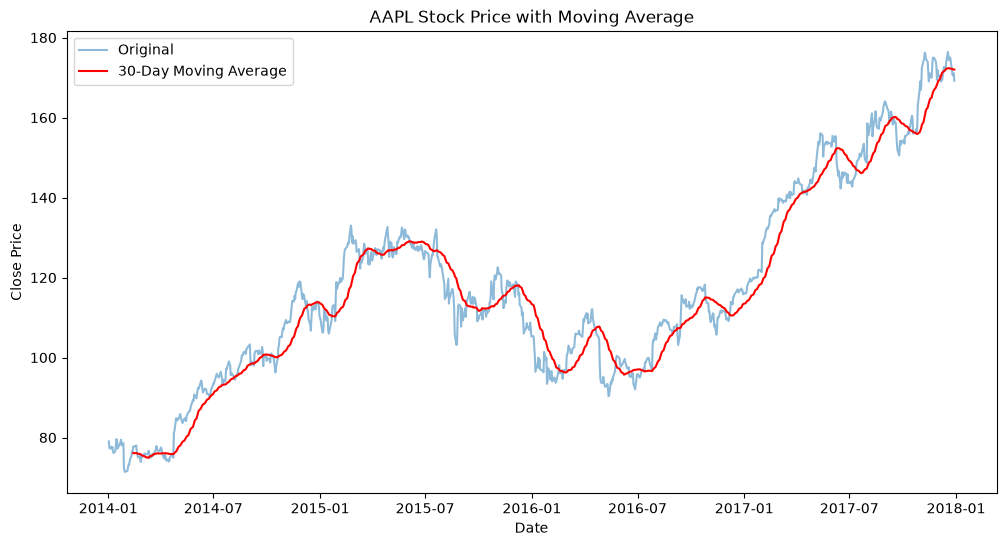

In [13]:
df_single['MA_30'] = df_single['close'].rolling(window=30).mean()

plt.figure(figsize=(12, 6))
plt.plot(df_single['close'], label='Original', alpha=0.5)
plt.plot(df_single['MA_30'], label='30-Day Moving Average', color='red')
plt.title('AAPL Stock Price with Moving Average')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

Observations:
- The stock price shows an overall upward trend over time.
- The moving average smooths short-term fluctuations and makes the trend clearer.
- The seasonal decomposition shows a repeating seasonal pattern and residual noise.